# 3사 멀티턴 KV 캐싱 비교 — 10턴 누적 대화

**비교 대상 4모델**

| Provider | 모델 | 캐싱 방식 | 캐시 쓰기 |
|---|---|---|---|
| OpenAI | `gpt-5.6-luna` | 자동 프리픽스 | **1.25배 과금** (`cache_write_tokens`) |
| OpenAI | `gpt-5.4-mini` | 자동 프리픽스 | 무료 (필드 항상 `None`) |
| Anthropic | `claude-opus-4-8` | 명시적 `cache_control` (증분) | **1.25배 과금** (`cache_creation_input_tokens`) |
| Google | `gemini-3.6-flash` | 암시적 (자동, 비보장) | 무료 |

> 💡 **GPT 5.6 부터 OpenAI 도 캐시 쓰기/읽기가 분리됩니다.** 실측 확인:
> `gpt-5.6-luna` 는 콜드 요청에서 `prompt_tokens_details.cache_write_tokens` 에 실제 값이 찍히고
> 웜 요청에서 `cached_tokens` 로 넘어갑니다. `gpt-5.5`/`gpt-5.4-mini` 는 이 필드가 **항상 `None`** 입니다.
> 그래서 이 노트북의 로그는 5.6 계열과 Anthropic 만 `read=... write=...` 형식으로 둘 다 찍고,
> 나머지는 `cached=...` 하나만 찍습니다.
>
> 실무 함의: 5.6 부터는 **재사용 없는 1회성 요청이 오히려 1.25배 비쌉니다.** 5.5 이하엔 없던 리스크입니다.

## 왜 멀티턴인가
앞선 4개 폴더의 단발 벤치마크는 "같은 프리픽스를 반복하면 캐시가 걸리나"를 봤습니다.
하지만 실제 챗·에이전트는 **턴마다 대화가 누적**되고, 이전 턴 전체가 다음 턴의 프리픽스가 됩니다.
그래서 진짜 궁금한 건 이겁니다 — **턴이 쌓일수록 캐시가 계단식으로 따라 붙는가?**

이상적인 동작은 이렇습니다.
```
턴1: [시스템+질문1]                    → 캐시 0     (전량 새로 처리)
턴2: [시스템+질문1+답변1+질문2]        → 캐시 = 턴1 분량
턴3: [시스템+...+질문3]                → 캐시 = 턴2 분량
...  이전 턴 전체가 캐시에서 읽히고, 새로 추가된 부분만 새로 처리
```

## "하나의 캐싱 기준" — 통일한 것과 통일할 수 없는 것

**통일한 것 (공정 비교를 위해)**
- 동일한 시스템 프롬프트 (~2,000 토큰 — 3사 최소 캐싱 임계 1024 를 모두 넘김)
- 동일한 10턴 질문 시퀀스 (각 턴에 ~700 토큰짜리 로그 발췌 첨부 → 에이전트 대화 모사)
- 동일한 출력 한도(`MAX_OUTPUT_TOKENS`), `temperature=0`, 스트리밍 TTFT 측정
- 동일한 지표: 턴별 `prompt_tokens` / 캐시 토큰 / 적중률 / TTFT / latency / 누적 비용

**통일할 수 없는 것 (API 구조가 다름)**
- **OpenAI** — 자동. 개발자가 할 일은 `prompt_cache_key` 고정뿐.
- **Anthropic** — 명시적. 매 턴 **마지막 user 블록에 `cache_control` 을 이동**시켜야 이전 대화까지 캐시가 확장됩니다(증분 캐싱). 이전 턴 블록의 `cache_control` 은 제거합니다 (breakpoint 최대 4개 제한).
- **Google** — 암시적. 설정할 게 없고 보장도 없습니다.

즉 **"캐시가 이전 턴까지 확장되게 하는 각 API 의 권장 방식"** 을 기준으로 맞췄습니다.

> ⚠️ 토크나이저가 달라 같은 텍스트라도 모델별 `prompt_tokens` 가 다릅니다.
> 그래서 절대 토큰 수보다 **적중률(%)** 로 비교하세요.
> 단가도 일부 모델은 플레이스홀더라 **모델 간 절대 금액 비교는 무의미**합니다 — 각 모델의 **절감률(%)** 을 보세요.

## 실행 전 체크리스트

1. **`.env`** 에 `OPENAI_API_KEY`, `ANTHROPIC_API_KEY`, `GOOGLE_API_KEY` 가 모두 있어야 합니다.
2. **Gemini 무료 티어 쿼터** — 이 노트북은 Gemini 를 10회 호출합니다. 같은 날 `gemini36/` 폴더의 단발 벤치마크를 여러 번 돌렸다면 **무료 쿼터가 이미 소진돼 429 가 납니다.** 쿼터가 회복된 뒤 실행하거나 유료 티어를 쓰세요.
3. **한 번에 이어서 실행하세요.** 캐시 TTL 이 수 분이라 셀을 띄엄띄엄 실행하면 중간에 evict 되어 적중률이 떨어집니다.
4. 총 소요 시간은 **약 3~5분**입니다 (Gemini 스로틀링이 대부분).

> 💡 어느 모델이 중간에 실패해도 **그 턴까지의 결과는 보존**되고 나머지 모델은 계속 실행됩니다.
> 표에서 `—` 로 표시된 턴은 그 모델이 완주하지 못한 구간입니다.


In [1]:
# === 셋업 ===
import json, os, pathlib, re, statistics, time

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    pass

# ------- 공통 실험 설정 -------
N_TURNS           = 10     # 대화 턴 수
MAX_OUTPUT_TOKENS = 96     # 출력 한도 (턴마다 컨텍스트가 누적되도록 어느 정도 길이 확보)

# ⚠️ temperature 는 3사 공통으로 **보내지 않습니다** (각 모델 기본값 사용).
#    실측 확인: gpt-5.6-luna 는 temperature=0 을 거부하고(기본 1만 허용),
#              claude-opus-4-8 은 temperature 자체가 deprecated 라 400 이 납니다.
#    캐시 적중은 프리픽스 일치 여부로 정해지므로 샘플링 온도와 무관합니다.

# ------- 모델 & 단가 ($ / 1M tokens) -------
# write_mult = 캐시 '쓰기' 단가 배수. 이 값이 있는 모델은 콜드 요청에서 쓰기 비용을 따로 냅니다.
#   · GPT 5.6 이상 — 쓰기 1.25배 (5.5 이하는 쓰기 무료라 write_mult 없음)
#   · Anthropic    — 쓰기 1.25배 (5분 TTL 기준)
# ⚠️ price_note 가 "플레이스홀더"인 모델은 절대 금액이 부정확합니다. 절감률(%)만 신뢰하세요.
MODELS = [
    {"key": "gpt-5.6-luna",    "provider": "openai",
     "in": 1.00, "cached_in": 0.10, "out": 6.00,  "price_note": "공식 pricing 확인값",
     "write_mult": 1.25},
    {"key": "gpt-5.4-mini",    "provider": "openai",
     "in": 0.75, "cached_in": 0.075, "out": 4.50,  "price_note": "공식 pricing 확인값 (쓰기 무료)"},
    {"key": "claude-opus-4-8", "provider": "anthropic",
     "in": 5.00, "cached_in": 0.50,  "out": 25.00, "price_note": "입력가 기존 기준 / 출력가 플레이스홀더",
     "write_mult": 1.25},
    {"key": "gemini-3.6-flash", "provider": "google",
     "in": 0.30, "cached_in": 0.03,  "out": 2.50,  "price_note": "플레이스홀더"},
]

# Gemini 무료 티어는 분당 5회 제한 — 유료면 실제 한도로 올리세요 (None 이면 스로틀링 없음)
GEMINI_RPM_LIMIT = 5

print(f"턴 수: {N_TURNS} | 출력한도: {MAX_OUTPUT_TOKENS} | 모델 {len(MODELS)}종")
for m in MODELS:
    print(f"  - {m['key']:18s} ({m['provider']}) 단가: {m['price_note']}")

턴 수: 10 | 출력한도: 96 | 모델 4종
  - gpt-5.6-luna       (openai) 단가: 공식 pricing 확인값
  - gpt-5.4-mini       (openai) 단가: 공식 pricing 확인값 (쓰기 무료)
  - claude-opus-4-8    (anthropic) 단가: 입력가 기존 기준 / 출력가 플레이스홀더
  - gemini-3.6-flash   (google) 단가: 플레이스홀더


In [2]:
# === 공통 시나리오: 시스템 프롬프트 + 10턴 질문 ===
# 3사 최소 캐싱 임계(1024 토큰)를 모두 넘기도록 시스템 프롬프트를 충분히 크게 만듭니다.
_RUNBOOK_UNIT = (
    "Operational rule: every deployment must be preceded by a snapshot of the current configuration so that "
    "before/after comparison is possible. Staging must reproduce the change and pass regression tests first. "
    "Production changes follow the four-eyes principle and are applied only inside a scheduled maintenance window. "
    "After rollout, metrics are observed for 30 minutes and rolled back immediately on anomaly. "
    "P1 incidents require initial response within 15 minutes and an RCA report within 3 business days. "
)
SYSTEM_PROMPT = (
    "You are a site reliability engineer assistant for the 'orderhub' service. "
    "Answer strictly from the operations runbook below. Keep every answer to at most two sentences.\n\n"
    + _RUNBOOK_UNIT * 22
)

# 각 턴에 첨부되는 로그 발췌 — 턴마다 컨텍스트가 눈에 띄게 늘어나야 캐시 계단이 보입니다.
_LOG_UNIT = (
    "[{ts}] svc=order-api level=warn msg=\"retry scheduled\" attempt={n} latency_ms={lat} "
    "consumer=inbox-worker partition={p} offset={off} idempotency_key=ord-{n:06d} "
)


def make_log_excerpt(turn: int, lines: int = 18) -> str:
    return "".join(
        _LOG_UNIT.format(ts=f"12:{turn:02d}:{i:02d}", n=turn * 100 + i,
                         lat=120 + i * 7, p=i % 4, off=turn * 1000 + i)
        for i in range(lines)
    )


QUESTIONS = [
    "이 로그에서 재시도가 반복되는 원인으로 가장 먼저 의심할 것은?",
    "inbox 테이블과 같은 트랜잭션으로 묶어야 하는 이유를 한 줄로 설명해줘.",
    "P1 장애 초동 대응 시간과 RCA 제출 기한은?",
    "운영 반영 시 4-eyes 원칙이 뭘 뜻하지?",
    "롤백 판단 기준으로 관찰해야 하는 시간은?",
    "스테이징에서 반드시 통과시켜야 하는 건 뭐야?",
    "배포 전에 스냅샷을 남기는 목적은?",
    "idempotency key 를 메시지 id 에서 파생시키는 이유는?",
    "유지보수 window 밖에 운영 반영을 하면 안 되는 이유는?",
    "지금까지 대화를 한 문장으로 요약해줘.",
][:N_TURNS]


def user_text(turn: int) -> str:
    """턴 t 의 사용자 메시지 = 로그 발췌 + 질문 (모든 모델에 동일하게 들어감)."""
    return f"[로그 발췌 turn {turn}]\n{make_log_excerpt(turn)}\n\n질문: {QUESTIONS[turn - 1]}"


print(f"시스템 프롬프트 길이: {len(SYSTEM_PROMPT):,}자")
print(f"턴당 사용자 메시지 길이: 약 {len(user_text(1)):,}자")
print(f"질문 {len(QUESTIONS)}개 준비 완료")

시스템 프롬프트 길이: 11,302자
턴당 사용자 메시지 길이: 약 2,900자
질문 10개 준비 완료


In [3]:
# === OpenAI 러너 (자동 프리픽스 캐싱) ===
from openai import OpenAI

_oa = OpenAI()


def run_openai(model_cfg):
    """messages 를 턴마다 누적하며 호출. prompt_cache_key 를 고정해 같은 캐시로 라우팅."""
    model = model_cfg["key"]
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    rows = []
    for turn in range(1, N_TURNS + 1):
        messages.append({"role": "user", "content": user_text(turn)})

        try:
            t0 = time.perf_counter()
            ttft, usage, chunks = None, None, []
            stream = _oa.chat.completions.create(
                model=model, messages=messages,
                max_completion_tokens=MAX_OUTPUT_TOKENS,
                stream=True, stream_options={"include_usage": True},
                prompt_cache_key=f"multiturn-{model}",
            )
            for ch in stream:
                if ch.choices:
                    if ttft is None:
                        ttft = time.perf_counter() - t0
                    d = ch.choices[0].delta
                    if getattr(d, "content", None):
                        chunks.append(d.content)
                if getattr(ch, "usage", None) is not None:
                    usage = ch.usage
            total = time.perf_counter() - t0
            ttft = ttft if ttft is not None else total
        except Exception as e:
            # 한 턴이 실패해도 그때까지의 결과는 살린다 (전체 폐기 방지)
            print(f"  ⚠️ 턴{turn} 실패 — 여기까지 결과로 진행: {type(e).__name__}: {str(e)[:150]}")
            break

        ptoks = usage.prompt_tokens if usage else 0
        otoks = usage.completion_tokens if usage else 0
        cached = write = 0
        if usage and getattr(usage, "prompt_tokens_details", None):
            ptd = usage.prompt_tokens_details
            cached = ptd.cached_tokens or 0
            # ⚠️ GPT 5.6 이상만 실제 값이 들어옵니다. 5.5 이하는 항상 None → 0
            write = getattr(ptd, "cache_write_tokens", None) or 0

        write_mult = model_cfg.get("write_mult")          # 5.6 이상만 존재 (쓰기 1.25배)
        uncached = ptoks - cached - write
        cost = (uncached * model_cfg["in"]
                + write * model_cfg["in"] * (write_mult or 1.0)
                + cached * model_cfg["cached_in"]
                + otoks * model_cfg["out"]) / 1_000_000
        # 캐싱이 전혀 없었다면 냈을 비용 (절감률 계산용)
        cost_nocache = (ptoks * model_cfg["in"] + otoks * model_cfg["out"]) / 1_000_000

        answer = "".join(chunks) or "(빈 응답)"
        messages.append({"role": "assistant", "content": answer})
        rows.append({"turn": turn, "prompt_tokens": ptoks, "cached": cached, "write": write,
                     "output_tokens": otoks, "ttft": ttft, "total": total,
                     "cost": cost, "cost_nocache": cost_nocache})
        # 쓰기/읽기가 분리되는 모델(5.6 이상)은 Anthropic 과 같은 형식으로 둘 다 찍는다
        rate = cached / ptoks if ptoks else 0
        if write_mult:
            print(f"  턴{turn:2d}: prompt={ptoks:>7,} read={cached:>7,} ({rate:>5.1%}) write={write:>6,} "
                  f"TTFT={ttft * 1000:>6.0f}ms cost=${cost:.5f}")
        else:
            print(f"  턴{turn:2d}: prompt={ptoks:>7,} cached={cached:>7,} ({rate:>5.1%}) "
                  f"TTFT={ttft * 1000:>6.0f}ms cost=${cost:.5f}")
    return rows

In [4]:
# === Anthropic 러너 (명시적 cache_control — 증분 캐싱) ===
import anthropic

_an = anthropic.Anthropic()


def run_anthropic(model_cfg):
    """매 턴 '마지막 user 블록'으로 cache_control 을 이동시켜 이전 대화까지 캐시를 확장한다.
    이전 턴 블록의 cache_control 은 제거 — breakpoint 는 최대 4개까지만 허용되기 때문.
    """
    model = model_cfg["key"]
    system_blocks = [{"type": "text", "text": SYSTEM_PROMPT,
                      "cache_control": {"type": "ephemeral"}}]
    messages, rows = [], []
    prev_user_block = None

    for turn in range(1, N_TURNS + 1):
        if prev_user_block is not None:
            prev_user_block.pop("cache_control", None)   # 직전 턴의 breakpoint 회수
        block = {"type": "text", "text": user_text(turn), "cache_control": {"type": "ephemeral"}}
        messages.append({"role": "user", "content": [block]})
        prev_user_block = block

        try:
            t0 = time.perf_counter()
            ttft, chunks = None, []
            with _an.messages.stream(model=model, max_tokens=MAX_OUTPUT_TOKENS,
                                     system=system_blocks, messages=messages) as stream:
                for text in stream.text_stream:
                    if ttft is None:
                        ttft = time.perf_counter() - t0
                    chunks.append(text)
                msg = stream.get_final_message()
            total = time.perf_counter() - t0
            ttft = ttft if ttft is not None else total
        except Exception as e:
            print(f"  ⚠️ 턴{turn} 실패 — 여기까지 결과로 진행: {type(e).__name__}: {str(e)[:150]}")
            break

        u = msg.usage
        write, read = u.cache_creation_input_tokens, u.cache_read_input_tokens
        ptoks = u.input_tokens + write + read          # 전체 입력 토큰 (3필드 합)
        otoks = u.output_tokens
        cost = (u.input_tokens * model_cfg["in"]
                + write * model_cfg["in"] * model_cfg["write_mult"]
                + read * model_cfg["cached_in"]
                + otoks * model_cfg["out"]) / 1_000_000
        cost_nocache = (ptoks * model_cfg["in"] + otoks * model_cfg["out"]) / 1_000_000

        answer = "".join(chunks) or "(빈 응답)"
        messages.append({"role": "assistant", "content": [{"type": "text", "text": answer}]})
        rows.append({"turn": turn, "prompt_tokens": ptoks, "cached": read, "output_tokens": otoks,
                     "ttft": ttft, "total": total, "cost": cost, "cost_nocache": cost_nocache,
                     "write": write})
        print(f"  턴{turn:2d}: prompt={ptoks:>7,} read={read:>7,} ({read / ptoks if ptoks else 0:>5.1%}) "
              f"write={write:>6,} TTFT={ttft * 1000:>6.0f}ms cost=${cost:.5f}")
    return rows

In [5]:
# === Google 러너 (암시적 캐싱 + 무료 티어 스로틀/429 재시도) ===
from google import genai
from google.genai import types

_gg = genai.Client()
_last_call = [0.0]
_MIN_INTERVAL = (60.0 / GEMINI_RPM_LIMIT + 1.0) if GEMINI_RPM_LIMIT else 0.0


def _throttle():
    if not _MIN_INTERVAL or not _last_call[0]:
        return
    wait = _MIN_INTERVAL - (time.monotonic() - _last_call[0])
    if wait > 0:
        time.sleep(wait)


def _retry_delay_from(err) -> float:
    m = re.search(r"'retryDelay':\s*'(\d+(?:\.\d+)?)s'", str(err))
    return float(m.group(1)) + 2.0 if m else 30.0


def _with_retry(fn, max_tries=6):
    for attempt in range(1, max_tries + 1):
        _throttle()
        try:
            out = fn()
            _last_call[0] = time.monotonic()
            return out
        except Exception as e:
            _last_call[0] = time.monotonic()
            s = str(e)
            if ("429" not in s and "RESOURCE_EXHAUSTED" not in s) or attempt == max_tries:
                raise
            # ⚠️ 분당 한도(PerMinute)는 기다리면 풀리지만, 일일 한도(PerDay)는 재시도해도 소용없다.
            #    응답에 retryDelay 가 5초로 붙어 나와도 마찬가지 — 즉시 중단하는 게 맞다.
            if "PerDay" in s:
                raise RuntimeError(
                    "Gemini 일일 요청 한도(RequestsPerDay) 소진 — 재시도해도 풀리지 않습니다. "
                    "무료 티어는 이 모델이 하루 20회입니다. PT 자정 리셋을 기다리거나, "
                    "API 키가 속한 프로젝트에 결제가 연결됐는지(FreeTier 가 아닌지) 확인하세요."
                ) from e
            d = _retry_delay_from(e)
            print(f"    (429 분당 한도 — {d:.0f}s 대기 후 재시도)")
            time.sleep(d)


def run_google(model_cfg):
    """system_instruction 고정 + contents 를 턴마다 누적. 캐싱은 암시적이라 설정할 게 없다."""
    model = model_cfg["key"]
    config = types.GenerateContentConfig(
        system_instruction=SYSTEM_PROMPT,
        max_output_tokens=MAX_OUTPUT_TOKENS,
    )
    contents, rows = [], []
    for turn in range(1, N_TURNS + 1):
        contents.append(types.Content(role="user", parts=[types.Part(text=user_text(turn))]))

        def _run():
            t0 = time.perf_counter()
            ttft, usage, chunks = None, None, []
            for ch in _gg.models.generate_content_stream(model=model, contents=contents, config=config):
                if getattr(ch, "text", None):
                    if ttft is None:
                        ttft = time.perf_counter() - t0
                    chunks.append(ch.text)
                if getattr(ch, "usage_metadata", None) is not None:
                    usage = ch.usage_metadata
            total = time.perf_counter() - t0
            return (ttft if ttft is not None else total), total, usage, "".join(chunks)

        try:
            ttft, total, usage, answer = _with_retry(_run)
        except Exception as e:
            # 무료 티어 쿼터가 소진되면 여기서 멈추고 그때까지 결과만 남긴다
            print(f"  ⚠️ 턴{turn} 실패 — 여기까지 결과로 진행: {type(e).__name__}: {str(e)[:150]}")
            break

        ptoks = (usage.prompt_token_count or 0) if usage else 0
        otoks = (usage.candidates_token_count or 0) if usage else 0
        cached = (usage.cached_content_token_count or 0) if usage else 0   # None → 0 (미스 신호)
        cost = ((ptoks - cached) * model_cfg["in"] + cached * model_cfg["cached_in"]
                + otoks * model_cfg["out"]) / 1_000_000
        cost_nocache = (ptoks * model_cfg["in"] + otoks * model_cfg["out"]) / 1_000_000

        contents.append(types.Content(role="model", parts=[types.Part(text=answer or "(빈 응답)")]))
        rows.append({"turn": turn, "prompt_tokens": ptoks, "cached": cached, "output_tokens": otoks,
                     "ttft": ttft, "total": total, "cost": cost, "cost_nocache": cost_nocache})
        print(f"  턴{turn:2d}: prompt={ptoks:>7,} cached={cached:>7,} ({cached / ptoks if ptoks else 0:>5.1%}) "
              f"TTFT={ttft * 1000:>6.0f}ms cost=${cost:.5f}")
    return rows

In [6]:
# === 4모델 순차 실행 ===
RUNNERS = {"openai": run_openai, "anthropic": run_anthropic, "google": run_google}

results = {}
for cfg in MODELS:
    print(f"\n=== {cfg['key']} ({cfg['provider']}) — {N_TURNS}턴 ===")
    if cfg["provider"] == "google" and _MIN_INTERVAL:
        print(f"  (무료 티어 스로틀: 호출 간 {_MIN_INTERVAL:.0f}s → 약 {N_TURNS * _MIN_INTERVAL / 60:.1f}분 소요)")
    try:
        results[cfg["key"]] = {"cfg": cfg, "rows": RUNNERS[cfg["provider"]](cfg)}
    except Exception as e:
        print(f"  ❌ 실패: {type(e).__name__}: {str(e)[:200]}")
        results[cfg["key"]] = {"cfg": cfg, "rows": [], "error": str(e)[:500]}

print("\n완료:", ", ".join(k for k, v in results.items() if v["rows"]))


=== gpt-5.6-luna (openai) — 10턴 ===
  턴 1: prompt=  2,906 read=      0 ( 0.0%) write= 2,903 TTFT=  2661ms cost=$0.00421
  턴 2: prompt=  3,788 read=  2,903 (76.6%) write=   882 TTFT=  1350ms cost=$0.00187
  턴 3: prompt=  4,687 read=  3,785 (80.8%) write=   899 TTFT=   862ms cost=$0.00172
  턴 4: prompt=  5,588 read=  4,684 (83.8%) write=   901 TTFT=   995ms cost=$0.00180
  턴 5: prompt=  6,484 read=  5,585 (86.1%) write=   896 TTFT=  2192ms cost=$0.00190
  턴 6: prompt=  7,385 read=  6,481 (87.8%) write=   901 TTFT=   679ms cost=$0.00193
  턴 7: prompt=  8,273 read=  7,382 (89.2%) write=   888 TTFT=   759ms cost=$0.00203
  턴 8: prompt=  9,169 read=  8,270 (90.2%) write=   896 TTFT=   924ms cost=$0.00229
  턴 9: prompt= 10,067 read=  9,166 (91.0%) write=   898 TTFT=  1482ms cost=$0.00261
  턴10: prompt= 10,990 read= 10,064 (91.6%) write=   923 TTFT=  1831ms cost=$0.00274

=== gpt-5.4-mini (openai) — 10턴 ===
  턴 1: prompt=  2,906 cached=      0 ( 0.0%) TTFT=   832ms cost=$0.00251
  턴 2: prompt

In [7]:
# === 턴별 캐시 적중률 비교표 ===
ok = {k: v for k, v in results.items() if v["rows"]}

header = f"{'턴':>3} | " + " | ".join(f"{k:>22s}" for k in ok)
print(header)
print("-" * len(header))
# 모델마다 완주한 턴 수가 다를 수 있으므로(중간 실패 시 부분 결과 보존) 방어적으로 출력
for t in range(1, N_TURNS + 1):
    cells_out = []
    for k, v in ok.items():
        if t <= len(v["rows"]):
            r = v["rows"][t - 1]
            rate = r["cached"] / r["prompt_tokens"] if r["prompt_tokens"] else 0
            cells_out.append(f"{r['cached']:>8,}/{r['prompt_tokens']:>7,} {rate:>5.0%}")
        else:
            cells_out.append(f"{'—':>22s}")
    print(f"{t:>3} | " + " | ".join(cells_out))

print(f"\n[턴1 이후 평균 적중률]")
for k, v in ok.items():
    rest = v["rows"][1:]
    if not rest:
        print(f"  {k:20s} (턴 부족 — 완주 {len(v['rows'])}턴)")
        continue
    rates = [r["cached"] / r["prompt_tokens"] for r in rest if r["prompt_tokens"]]
    hits = sum(1 for r in rest if r["cached"] > 0)
    note = "" if len(v["rows"]) == N_TURNS else f"  ⚠️ {len(v['rows'])}턴만 완주"
    print(f"  {k:20s} {statistics.mean(rates):>6.1%}   (적중한 턴 {hits}/{len(rest)}){note}")

  턴 |           gpt-5.6-luna |           gpt-5.4-mini |        claude-opus-4-8 |       gemini-3.6-flash
-------------------------------------------------------------------------------------------------------
  1 |        0/  2,906    0% |        0/  2,906    0% |        0/  4,811    0% |        0/  3,249    0%
  2 |    2,903/  3,788   77% |    2,816/  3,853   73% |    4,809/  6,324   76% |        0/  4,426    0%
  3 |    3,785/  4,687   81% |    3,328/  4,765   70% |    6,322/  7,816   81% |        0/  5,593    0%
  4 |    4,684/  5,588   84% |    4,352/  5,665   77% |    7,814/  9,277   84% |        0/  6,759    0%
  5 |    5,585/  6,484   86% |    5,376/  6,589   82% |    9,275/ 10,771   86% |        0/  7,926    0%
  6 |    6,481/  7,385   88% |    6,400/  7,490   85% |   10,769/ 12,221   88% |        0/  9,090    0%
  7 |    7,382/  8,273   89% |    7,424/  8,394   88% |   12,219/ 13,659   89% |        0/ 10,255    0%
  8 |    8,270/  9,169   90% |    7,936/  9,311   85% |   13,657

In [8]:
# === 캐싱 절감 효과 (모델별 — 캐싱 미적용 대비) ===
# ⚠️ 단가가 플레이스홀더인 모델이 있어 모델 간 절대 금액 비교는 무의미합니다.
#    각 모델이 '캐싱을 안 썼을 때 대비' 얼마나 아꼈는지(%)를 보세요.
print(f"{'모델':22s} | {'실제 비용':>10s} | {'캐싱 없었다면':>12s} | {'절감률':>7s} | 단가 신뢰도")
print("-" * 80)
saving = {}
for k, v in ok.items():
    actual = sum(r["cost"] for r in v["rows"])
    nocache = sum(r["cost_nocache"] for r in v["rows"])
    pct = (1 - actual / nocache) * 100 if nocache else 0
    saving[k] = {"actual": actual, "nocache": nocache, "save_pct": pct}
    print(f"{k:22s} | ${actual:>9.4f} | ${nocache:>11.4f} | {pct:>6.1f}% | {v['cfg']['price_note']}")

print(f"\n[TTFT 추이 — 첫 턴 vs 마지막 턴]")
for k, v in ok.items():
    first, last = v["rows"][0], v["rows"][-1]
    grow = last["prompt_tokens"] / first["prompt_tokens"] if first["prompt_tokens"] else 0
    print(f"  {k:20s} 턴1 {first['ttft'] * 1000:>6.0f}ms → 턴{len(v['rows'])} {last['ttft'] * 1000:>6.0f}ms "
          f"(컨텍스트 {grow:.1f}배 증가)")
print("\n※ 캐싱이 잘 걸리면 컨텍스트가 몇 배로 커져도 TTFT 는 크게 늘지 않습니다 —")
print("   새로 추가된 부분만 prefill 하기 때문입니다. 이것이 멀티턴 캐싱의 핵심 효용입니다.")

모델                     |      실제 비용 |      캐싱 없었다면 |     절감률 | 단가 신뢰도
--------------------------------------------------------------------------------
gpt-5.6-luna           | $   0.0231 | $     0.0728 |   68.3% | 공식 pricing 확인값
gpt-5.4-mini           | $   0.0171 | $     0.0553 |   69.0% | 공식 pricing 확인값 (쓰기 무료)
claude-opus-4-8        | $   0.1800 | $     0.5919 |   69.6% | 입력가 기존 기준 / 출력가 플레이스홀더
gemini-3.6-flash       | $   0.0234 | $     0.0256 |    8.6% | 플레이스홀더

[TTFT 추이 — 첫 턴 vs 마지막 턴]
  gpt-5.6-luna         턴1   2661ms → 턴10   1831ms (컨텍스트 3.8배 증가)
  gpt-5.4-mini         턴1    832ms → 턴10    978ms (컨텍스트 3.8배 증가)
  claude-opus-4-8      턴1   1611ms → 턴10   1202ms (컨텍스트 3.8배 증가)
  gemini-3.6-flash     턴1   1687ms → 턴10   1821ms (컨텍스트 4.2배 증가)

※ 캐싱이 잘 걸리면 컨텍스트가 몇 배로 커져도 TTFT 는 크게 늘지 않습니다 —
   새로 추가된 부분만 prefill 하기 때문입니다. 이것이 멀티턴 캐싱의 핵심 효용입니다.


In [9]:
# === 캐시 쓰기(write) 리포트 — 쓰기/읽기가 분리되는 모델만 ===
# GPT 5.6 이상과 Anthropic 은 캐시 '쓰기'를 별도 필드로 리포트하고 1.25배로 과금합니다.
# GPT 5.5 이하와 Gemini 는 쓰기 개념이 없어(무료) 이 표에 나오지 않습니다.
writers = {k: v for k, v in ok.items() if v["cfg"].get("write_mult")}
if not writers:
    print("쓰기/읽기가 분리되는 모델이 이번 실행에 없습니다.")
else:
    for k, v in writers.items():
        rows = v["rows"]
        tot_write = sum(r.get("write", 0) for r in rows)
        tot_read = sum(r.get("cached", 0) for r in rows)
        mult = v["cfg"]["write_mult"]
        # 쓰기에 더 낸 돈 = write * 단가 * (배수 - 1)  /  읽기로 아낀 돈 = read * 단가 * (1 - 할인율)
        extra = tot_write * v["cfg"]["in"] * (mult - 1) / 1_000_000
        saved = tot_read * (v["cfg"]["in"] - v["cfg"]["cached_in"]) / 1_000_000
        print(f"[{k}]  쓰기 배수 {mult}x")
        print(f"  {'턴':>3} | {'write':>8} | {'read':>8}")
        for r in rows:
            print(f"  {r['turn']:>3} | {r.get('write', 0):>8,} | {r.get('cached', 0):>8,}")
        print(f"  합계 write {tot_write:,} / read {tot_read:,}")
        print(f"  → 쓰기로 더 낸 돈 ${extra:.5f} vs 읽기로 아낀 돈 ${saved:.5f} "
              f"= 순이득 ${saved - extra:+.5f}\n")

    print("※ 턴1 에 write 가 몰리고 이후 턴은 '새로 늘어난 만큼만' write 되는 게 정상입니다.")
    print("   매 턴 write 가 크게 잡히면 프리픽스가 깨지고 있다는 신호입니다(캐시를 새로 쓰는 중).")

[gpt-5.6-luna]  쓰기 배수 1.25x
    턴 |    write |     read
    1 |    2,903 |        0
    2 |      882 |    2,903
    3 |      899 |    3,785
    4 |      901 |    4,684
    5 |      896 |    5,585
    6 |      901 |    6,481
    7 |      888 |    7,382
    8 |      896 |    8,270
    9 |      898 |    9,166
   10 |      923 |   10,064
  합계 write 10,987 / read 58,320
  → 쓰기로 더 낸 돈 $0.00275 vs 읽기로 아낀 돈 $0.05249 = 순이득 $+0.04974

[claude-opus-4-8]  쓰기 배수 1.25x
    턴 |    write |     read
    1 |    4,809 |        0
    2 |    1,513 |    4,809
    3 |    1,492 |    6,322
    4 |    1,461 |    7,814
    5 |    1,494 |    9,275
    6 |    1,450 |   10,769
    7 |    1,438 |   12,219
    8 |    1,463 |   13,657
    9 |    1,444 |   15,120
   10 |    1,509 |   16,564
  합계 write 18,073 / read 96,549
  → 쓰기로 더 낸 돈 $0.02259 vs 읽기로 아낀 돈 $0.43447 = 순이득 $+0.41188

※ 턴1 에 write 가 몰리고 이후 턴은 '새로 늘어난 만큼만' write 되는 게 정상입니다.
   매 턴 write 가 크게 잡히면 프리픽스가 깨지고 있다는 신호입니다(캐시를 새로 쓰는 중).


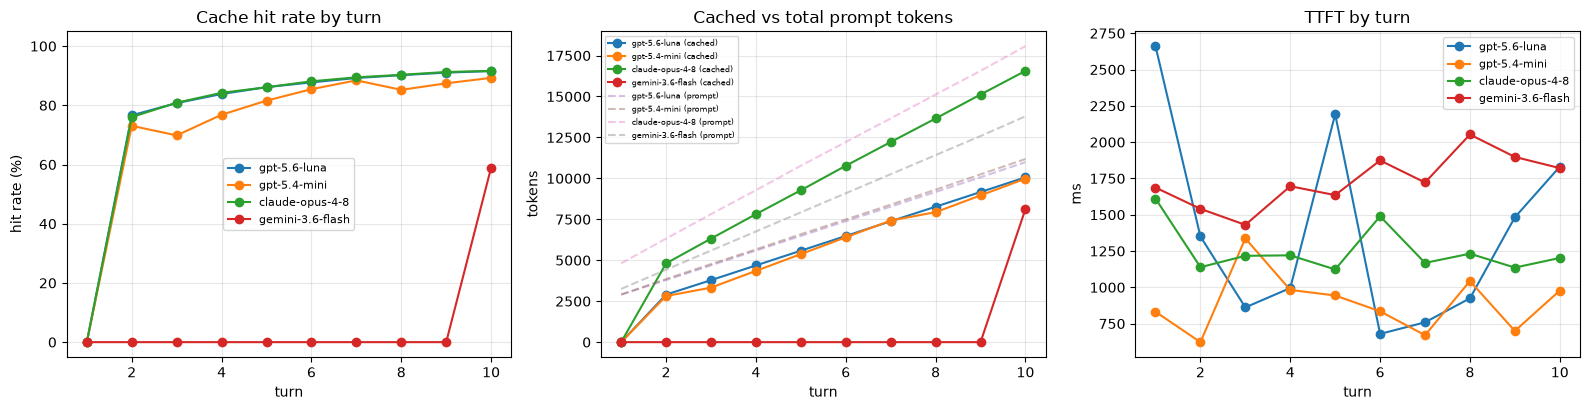

In [10]:
# === 비교 그래프 ===
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

    def _x(v):   # 모델마다 완주한 턴 수가 다를 수 있으므로 x축을 각자 길이에 맞춘다
        return list(range(1, len(v["rows"]) + 1))

    # (1) 턴별 캐시 적중률
    for k, v in ok.items():
        rates = [(r["cached"] / r["prompt_tokens"] * 100 if r["prompt_tokens"] else 0) for r in v["rows"]]
        axes[0].plot(_x(v), rates, marker="o", label=k)
    axes[0].set_title("Cache hit rate by turn")
    axes[0].set_xlabel("turn")
    axes[0].set_ylabel("hit rate (%)")
    axes[0].set_ylim(-5, 105)
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=8)

    # (2) 턴별 cached vs prompt 토큰 (계단식 증가 확인)
    for k, v in ok.items():
        axes[1].plot(_x(v), [r["cached"] for r in v["rows"]], marker="o", label=f"{k} (cached)")
    for k, v in ok.items():
        axes[1].plot(_x(v), [r["prompt_tokens"] for r in v["rows"]], linestyle="--", alpha=0.4,
                     label=f"{k} (prompt)")
    axes[1].set_title("Cached vs total prompt tokens")
    axes[1].set_xlabel("turn")
    axes[1].set_ylabel("tokens")
    axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=6)

    # (3) TTFT 추이
    for k, v in ok.items():
        axes[2].plot(_x(v), [r["ttft"] * 1000 for r in v["rows"]], marker="o", label=k)
    axes[2].set_title("TTFT by turn")
    axes[2].set_xlabel("turn")
    axes[2].set_ylabel("ms")
    axes[2].grid(alpha=0.3)
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print("시각화 건너뜀:", e)

In [11]:
# === 결과 저장 ===
payload = {
    "n_turns": N_TURNS,
    "max_output_tokens": MAX_OUTPUT_TOKENS,
    "models": {
        k: {
            "provider": v["cfg"]["provider"],
            "cache_mode": {"openai": "automatic-prefix", "anthropic": "explicit-cache_control",
                           "google": "implicit"}[v["cfg"]["provider"]],
            "price_note": v["cfg"]["price_note"],
            "rows": v["rows"],
            "avg_hit_rate_turn2plus": (
                statistics.mean([r["cached"] / r["prompt_tokens"] for r in v["rows"][1:] if r["prompt_tokens"]])
                if len(v["rows"]) > 1 else 0
            ),
            "cost_actual_usd": saving.get(k, {}).get("actual"),
            "cost_nocache_usd": saving.get(k, {}).get("nocache"),
            "cost_save_pct": saving.get(k, {}).get("save_pct"),
        }
        for k, v in ok.items()
    },
    "failed": {k: v.get("error") for k, v in results.items() if not v["rows"]},
}
out = pathlib.Path("multiturn_results.json")
out.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"저장: {out.resolve()}")
for k, m in payload["models"].items():
    print(f"  {k:20s} 평균 적중률(2턴~) {m['avg_hit_rate_turn2plus']:.1%} | 절감 {m['cost_save_pct']:.1f}%")

저장: /Users/user/jinsup_space/research/notebooks/kv_cache/multiturn_compare/multiturn_results.json
  gpt-5.6-luna         평균 적중률(2턴~) 86.4% | 절감 68.3%
  gpt-5.4-mini         평균 적중률(2턴~) 81.9% | 절감 69.0%
  claude-opus-4-8      평균 적중률(2턴~) 86.5% | 절감 69.6%
  gemini-3.6-flash     평균 적중률(2턴~) 6.5% | 절감 8.6%


## 결과 해석 가이드

### 봐야 할 것 1 — 턴1 은 원래 0% 입니다
어느 API든 첫 턴은 캐시에 아무것도 없으니 적중률 0% 가 정상입니다.
**턴2부터** 이전 턴이 캐시에서 읽히기 시작합니다. 그래서 위 표에서 "턴2 이후 평균"을 따로 냈습니다.

### 봐야 할 것 2 — 계단식으로 따라 붙는가
가운데 그래프에서 실선(cached)이 점선(prompt)을 **일정 간격 뒤에서 따라가면** 정상입니다.
간격이 곧 "이번 턴에 새로 추가돼 아직 캐시에 없는 몫"입니다.
실선이 점선에서 점점 멀어지거나 0 으로 떨어지면 캐시가 깨지고 있다는 뜻입니다.

### 봐야 할 것 3 — 컨텍스트가 커져도 TTFT 가 안 늘어나는가
멀티턴 캐싱의 진짜 효용은 여기 있습니다. 턴10 의 컨텍스트는 턴1 의 몇 배지만,
캐싱이 걸리면 **새로 추가된 부분만 prefill** 하므로 TTFT 가 비례해서 늘지 않습니다.
캐싱이 없다면 TTFT 가 컨텍스트에 비례해 우상향해야 합니다.

### 3사 구조적 차이가 멀티턴에서 드러나는 지점

| | OpenAI 5.6+ | OpenAI 5.5 이하 | Anthropic | Google (암시적) |
|---|---|---|---|---|
| 개발자가 할 일 | `prompt_cache_key` (선택) | 동일 | **매 턴 `cache_control` 이동** (필수) | 없음 |
| 안 하면? | 그래도 자동으로 걸림 | 동일 | **이전 대화가 캐시 안 됨** | — |
| 쓰기 비용 | **1.25배** | 없음 | 새로 캐시되는 몫에 1.25배 | 없음 |
| 캐시 TTL | `prompt_cache_options.ttl="30m"` (최소 30분 보장) | `prompt_cache_retention` (5~10분) | 5분 (`ttl:"1h"` 옵션) | 수 분 |
| 보장 | 프리픽스 일치 시 | 동일 | 프리픽스 일치 시 | **없음** |

**5.6 세대의 손익분기**: 쓰기 1.25배를 읽기 90% 할인으로 회수하려면 같은 프리픽스를 **약 1.3회 이상** 재사용해야 합니다 — Anthropic 과 같은 계산입니다. 멀티턴은 구조적으로 재사용이 보장되므로 거의 항상 이득이지만, **단발 요청 위주 워크로드라면 5.6 이 5.5 보다 비쌀 수 있습니다.** 위 '캐시 쓰기 리포트' 셀이 이 손익을 턴별로 보여줍니다.

- **Anthropic 은 손이 가는 대신 제어권이 있습니다.** `cache_control` 을 어디 찍느냐로 캐시 경계를 직접 정합니다. 다만 매 턴 새로 캐시되는 몫에 **쓰기 1.25배**를 내므로, 턴이 짧게 자주 오가면 쓰기 비용이 쌓입니다.
- **OpenAI 는 아무것도 안 해도 걸립니다.** 대신 캐시 경계를 제어할 수 없습니다.
- **Google 암시적은 가장 편하고 가장 불확실합니다.** 히트가 필요하면 명시적 캐싱(`client.caches.create`)을 쓰세요.

### 재현 시 주의
- 캐시 TTL 은 수 분입니다. 셀을 띄엄띄엄 실행하면 중간에 evict 되어 적중률이 뚝 떨어집니다 — **한 번에 이어서 실행**하세요.
- Gemini 무료 티어(분당 5회) 스로틀 때문에 호출 간 13초 간격이 생기고, 이것이 evict 확률을 높입니다. 유료 티어라면 `GEMINI_RPM_LIMIT` 을 올려 다시 재보세요.
- 토크나이저가 달라 모델별 `prompt_tokens` 가 다릅니다. **적중률(%)로 비교**하세요.
